# RNN model:

<a href="https://colab.research.google.com/github/TurkuNLP/Deep_Learning_in_LangTech_course/blob/master/hf_trainer_rnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

First, set up the required Python modules and perform some general configuration.

(This part of the code follows the [CNN notebook](https://github.com/TurkuNLP/Deep_Learning_in_LangTech_course/blob/master/hf_trainer_cnn.ipynb) that you should already be familiar with.)

Install the required Python packages using [pip](https://en.wikipedia.org/wiki/Pip):

* [`transformers`](https://huggingface.co/docs/transformers/index) is a popular deep learning package
* [`datasets`](https://huggingface.co/docs/datasets/) provides support for loading, creating, and manipulating datasets
* [`evaluate`](https://huggingface.co/docs/evaluate/index) is a library for easily evaluating machine learning models and datasets
* [`accelerate`](https://pypi.org/project/accelerate/) is a wrapper we need to install in order to train torch models using a transformers trainer

Both `transformers` and `datasets` are used extensively on this course.

In [1]:
#!pip3 install -q transformers datasets evaluate accelerate

(Above, the `!` at the start of the line tells the notebook to run the line as an operating system command rather than Python code, and the `-q` argument to `pip` runs the command in "quiet" mode, with less output.)

We'll also use the [`pprint`](https://docs.python.org/3/library/pprint.html) ("pretty-print") module to format output more readably below. The only difference to just using `print` is that some data structures will be easier to read and interpret.

In [2]:
from pprint import PrettyPrinter

pprint = PrettyPrinter(compact=True).pprint

Finally, we will reduce logging output. The `transformers` library by default produces fairly verbose logging. Commenting out the following code will enable low-priority output (`INFO` logging level and below).

In [3]:
import logging

logging.disable(logging.INFO)

---

# Download and prepare data

We will again use the `datasets` library function [`load_dataset`](https://huggingface.co/docs/datasets/master/en/package_reference/loading_methods#datasets.load_dataset) to load a dataset for our experiments.

In [4]:
import datasets


dataset = datasets.load_dataset("imdb")

Let's see what the dataset contains:

In [5]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


and print out an example:

In [6]:
dataset = dataset.shuffle()
del dataset["unsupervised"]
pprint(dataset["train"][0])

{'label': 0,
 'text': "That's right, you heard me this movie is a freaking' ABOMINATION. "
         'First off, the band, who the hell is going to go see or listen to a '
         'band called "THE NAKED BROTHERS BAND"?!?! Not only is the name '
         "terrible but so are the musicians, they can't even play anything! "
         'Also, the lead singer sounds more girly than Geddy Lee, and even '
         'more his voice is horrible! Not only are they terrible musicians but '
         "they're terrible actors. Led by a crappy director and thin plot, "
         'this has got to be the dumbest movie ever. I wish this website would '
         'let you use a vote of ZERO OR BELOW out of 10, because giving this '
         "filth a 1/10 is being WAY too generous.<br /><br />I'm not sure that "
         "you can call this a comedy film. If you're looking for comedy with "
         'music, go to that "Weird Al" Yankovic guy \'cause he does it a whole '
         'lot better than these untalent

---

# Tokenize and vectorize data

(This part of the code follows the [CNN notebook](https://github.com/TurkuNLP/Deep_Learning_in_LangTech_course/blob/master/hf_trainer_cnn.ipynb) that you should already be familiar with.)

To tokenize and vectorize the texts of our dataset, we will again use previously created tokenizers through the simple [`AutoTokenizer`](https://huggingface.co/docs/transformers/model_doc/auto#transformers.AutoTokenizer) class.

The [`AutoTokenizer.from_pretrained`](https://huggingface.co/docs/transformers/model_doc/auto#transformers.AutoTokenizer.from_pretrained) function can load the tokenizer associated with any of the large number of models found in the [Hugging Face models repository](https://huggingface.co/models). Here, our texts are in English, and we'll load the tokenizer for the [`bert-base-cased`](https://huggingface.co/bert-base-cased) model.

(**Note**: we're not actually using the BERT model here, just its tokenizer.)

In [7]:
import transformers

model_name = "bert-base-cased"
tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)

As in the [CNN notebook](https://github.com/TurkuNLP/Deep_Learning_in_LangTech_course/blob/master/hf_trainer_cnn.ipynb), we will define a simple tokenization function and tokenize and vectorize our whole dataset with the tokenizer by calling the [`Dataset.map`](https://huggingface.co/docs/datasets/v2.14.4/en/package_reference/main_classes#datasets.Dataset.map) function.

Note that here we're providing a `max_length` argument and `truncation=True` in the tokenizer call. This limits the maximum length of outputs to the given length (see the [tokenizers documentation](https://huggingface.co/docs/transformers/preprocessing#everything-you-always-wanted-to-know-about-padding-and-truncation) for details). This makes training faster, potentially at some cost in performance.

In [8]:
# Define a simple function that applies the tokenizer
def tokenize(example):
    return tokenizer(
        example["text"],
        max_length=128,
        truncation=True,
    )

# Apply the tokenizer to the whole dataset using .map()
dataset = dataset.map(tokenize)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

---

# Build model

As usual, we will create a PyTorch model class with an `__init__()` function that creates the layers and a `forward()` function which implements the actual computation. For more information on these, please see the [PyTorch tutorial](https://pytorch.org/tutorials/beginner/introyt/modelsyt_tutorial.html).

We're here building a simple RNN with the following structure:

* As in the [CNN](https://github.com/TurkuNLP/Deep_Learning_in_LangTech_course/blob/master/hf_trainer_cnn.ipynb), the token IDs are first mapped to embeddings of a user-specified size (`config.embedding_dim`) in a [torch.nn.Embedding](https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html) layer. Note that here the embeddings are initialized randomly and learned along with other model weights. In real-world applications, the embeddings would typically be initialized with previously learned weights.
* Second, the embedded inputs are passed through an RNN ([torch.nn.RNN](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html)), which produces a series of outputs ($(y_1, \ldots, y_n)$, where $n$ is the length of the input) and the final hidden state $h_n$. Here, we will only use the last output $y_n$.
* Finally, there is a fully connected layer ([torch.nn.Linear](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html)) that maps the last RNN output to the two possible output values of the classifier.

We can interpret this model as processing the input step by step, attempting to identify tokens (embeddings) that in the context of its previous input express either positive or negative opinions, and to output a value at the end of the sequence that can be mapped to the positive or negative class.

In the `forward` function we mostly just pass the input through the layers, with the following additional steps:

* To invoke the RNN, we need to provide the value of the initial hidden state $h_0$. Here we simply use [torch.zeros](https://pytorch.org/docs/stable/generated/torch.zeros.html) to create a tensor of the appropriate size filled with zeros.
* To get the value of the last item in the sequence of RNN outputs (`rnn_outputs`), we slice the three-dimensional tensor (batch, rnn step, output dim) with `rnn_outputs[:, -1, :]`. This returns all values in the first and last dimensions, and the last in the second. If you are not familar with this syntax, consider the following example:

In [9]:
import numpy

a = numpy.array([
  [[11], [12], [13]],
  [[21], [22], [23]],
  [[31], [32], [33]],
])

print(a[:, -1, :])

[[13]
 [23]
 [33]]


(The two points above can be considered technical details and understanding them in detail is not required to understand the model.)

Here's the model:

In [10]:
import torch


# This gives a new name to the config class, just for convenience
BasicConfig = transformers.PretrainedConfig


# This is the model
class SimpleRNN(transformers.PreTrainedModel):

    config_class = BasicConfig

    # In the initialization method, one instantiates the layers
    # these will be the parameters of the model
    def __init__(self, config):
        super().__init__(config)
        # Embedding layer: vocab size x embedding dim
        self.embeddings = torch.nn.Embedding(
            num_embeddings=config.vocab_size,
            embedding_dim=config.embedding_dim
        )
        # RNN with configurable hidden size and nonlinearity
        self.rnn = torch.nn.RNN(
            input_size=config.embedding_dim,
            hidden_size=config.hidden_size,
            num_layers=config.num_layers,
            nonlinearity=config.nonlinearity,
            batch_first=True
        )
        # Output layer: embedding size to output size
        self.output_layer = torch.nn.Linear(
            in_features=config.hidden_size,
            out_features=config.num_labels
        )
        # Loss function: standard loss for classification
        self.loss = torch.nn.CrossEntropyLoss()

    def forward(self, input_ids, labels=None, attention_mask=None):
        # Embed input ids
        x = self.embeddings(input_ids)
        # Set initial hidden state to all-zero values
        batch_size = x.shape[0]
        h0 = torch.zeros(
            (self.config.num_layers, batch_size, self.config.hidden_size),
            device=input_ids.device    # place on same device as input
        )
        # Run RNN repeatedly to get sequence of outputs and last hidden state
        rnn_outputs, h_n = self.rnn(x, h0)
        # Get last RNN output
        y_n = rnn_outputs[:, -1, :]
        # Map to outputs with fully connected layer
        output = self.output_layer(y_n)

        # Return value computed as in CNN:
        if labels is not None:
            # We have labels, so we can calculate the loss
            return (self.loss(output,labels), output)
        else:
            # No labels, so just return the output
            return (output,)

---

# Configure and train model

We'll first configure and instantiate the model. Here `vocab_size` should always be the vocabulary size of the tokenizer and `num_labels` the number of unique labels in the data (as here), but the others are hyperparameters that you can choose:

* `embedding_dim`: the size of the word (i.e. token) embeddings
* `hidden_size`: the size of the RNN hidden state vector _h_
* `num_layers`: number of stacked RNN layers
* `nonlinearity`: the non-linear function to apply in RNN (`'tanh'` or `'relu'`)

In [11]:
config = BasicConfig(
    vocab_size = tokenizer.vocab_size,
    num_labels = len(set(dataset["train"]["label"])),
    embedding_dim = 64,
    hidden_size = 96,
    num_layers = 1,
    nonlinearity = "tanh",
)

model = SimpleRNN(config)

Training arguments are set similarly as in the [CNN notebook](https://github.com/TurkuNLP/Deep_Learning_in_LangTech_course/blob/master/hf_trainer_cnn.ipynb). Many number of these settings relate to the frequency of evaluation and output during training, but the following are hyperparameters that you may wish to adjust:

* `learning_rate`: the step size for weight updates
* `per_device_train_batch_size`: number of examples per batch
* `max_steps`: the maximum number of steps to train for

In [12]:
# Set training arguments
trainer_args = transformers.TrainingArguments(
    "checkpoints",
    eval_strategy="steps",
    logging_strategy="steps",
    load_best_model_at_end=True,
    eval_steps=500,
    logging_steps=500,
    learning_rate=0.001,
    per_device_train_batch_size=96,
    max_steps=5000,
    report_to="none",
)

| Values | Training loss | Validation loss | Accuracy |
| :- | :- | :- | :- |
| learning_rate=0.001, per_device_train_batch_size=32, max_steps=2500, | 0.644295 | 0.669598 | 0.607920
| learning_rate=0.05, per_device_train_batch_size=32, max_steps=2500, | 0.712525 | 0.694036 | 0.507520
| learning_rate=0.001, per_device_train_batch_size=32, max_steps=5000, | 0.541378 | 0.660101 | 0.658920
| learning_rate=0.001, per_device_train_batch_size=64, max_steps=5000, | 0.461722 | 0.699457 | 0.666800
| learning_rate=0.001, per_device_train_batch_size=64, max_steps=5000, | 0.427396 | 0.675484 | 0.688440
| learning_rate=0.001, per_device_train_batch_size=64, max_steps=5000, stopped at 4000 steps| 0.368515 | 0.773370 | 0.678520
| learning_rate=0.001, per_device_train_batch_size=96, max_steps=5000| 0.358406 | 0.734633 | 0.684520

We'll then define the standard accuracy metric (ratio of correct out of all predictions), create a [DataCollatorWithPadding](https://huggingface.co/docs/transformers/main_classes/data_collator#transformers.DataCollatorWithPadding) to pad inputs to the same length (as required for batching) and an [EarlyStoppingCallback](https://huggingface.co/docs/transformers/main_classes/callback#transformers.EarlyStoppingCallback) to stop training when performance fails to improve for the given number of evaluations.

(These should all be familiar to you from the [CNN notebook](https://github.com/TurkuNLP/Deep_Learning_in_LangTech_course/blob/master/hf_trainer_cnn.ipynb))

In [13]:
import evaluate
accuracy = evaluate.load("accuracy")


def compute_accuracy(outputs_and_labels):
    outputs, labels = outputs_and_labels
    predictions = outputs.argmax(axis=-1) #pick the index of the "winning" label
    return accuracy.compute(predictions=predictions, references=labels)

data_collator = transformers.DataCollatorWithPadding(tokenizer)

# Argument gives the number of steps of patience before early stopping
early_stopping = transformers.EarlyStoppingCallback(
    early_stopping_patience=5
)

Finally, as in the [CNN notebook](https://github.com/TurkuNLP/Deep_Learning_in_LangTech_course/blob/master/hf_trainer_cnn.ipynb), we'll create a simple custom [callback](https://huggingface.co/docs/transformers/main_classes/callback) to store values logged during training so that we can more easily examine them later. (This is only needed for visualization and is not necessary to understand in detail.)

In [14]:
from collections import defaultdict

class LogSavingCallback(transformers.TrainerCallback):
    def on_train_begin(self, *args, **kwargs):
        self.logs = defaultdict(list)
        self.training = True

    def on_train_end(self, *args, **kwargs):
        self.training = False

    def on_log(self, args, state, control, logs, model=None, **kwargs):
        if self.training:
            for k, v in logs.items():
                if k != "epoch" or v not in self.logs[k]:
                    self.logs[k].append(v)

training_logs = LogSavingCallback()

We then pass the model, trainer arguments, training and evaluation data, metric, the collator, and the callbacks to a [Trainer](https://huggingface.co/docs/transformers/main_classes/trainer) and call `.train()` to train the model.

In [15]:
trainer = transformers.Trainer(
    model=model,
    args=trainer_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    compute_metrics=compute_accuracy,
    data_collator=data_collator,
    callbacks=[early_stopping, training_logs]
)

trainer.train()

/home/lauris/Documents/school/2026-27/Deep-Learning/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss,Validation Loss,Accuracy
500,0.691953,0.685504,0.572080
1000,0.666444,0.664542,0.620080
1500,0.619416,0.663553,0.647400
2000,0.573037,0.656904,0.660920
2500,0.520723,0.683638,0.680040
3000,0.476777,0.687128,0.671160
3500,0.434884,0.709110,0.680880
4000,0.402424,0.729030,0.675080
4500,0.377337,0.745577,0.685520


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/home/lauris/Documents/school/2026-27/Deep-Learning/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

/home/lauris/Documents/school/2026-27/Deep-Learning/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/home/lauris/Documents/school/2026-27/Deep-Learning/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4500, training_loss=0.5292216796875, metrics={'train_runtime': 158.9209, 'train_samples_per_second': 3020.371, 'train_steps_per_second': 31.462, 'total_flos': 5212632428544.0, 'train_loss': 0.5292216796875, 'epoch': 17.24137931034483})

---

# Results

Evaluate and print out results:

In [16]:
#eval_results = trainer.evaluate(dataset["test"])

#pprint(eval_results)

#print('Accuracy:', eval_results['eval_accuracy'])

Let's also have a look at training and evaluation loss and evaluation accuracy progression as we did in the [CNN notebook](https://github.com/TurkuNLP/Deep_Learning_in_LangTech_course/blob/master/hf_trainer_cnn.ipynb). (The code here is only for visualization and you do not need to understand it, but you should aim to be able to interpret the plots.)

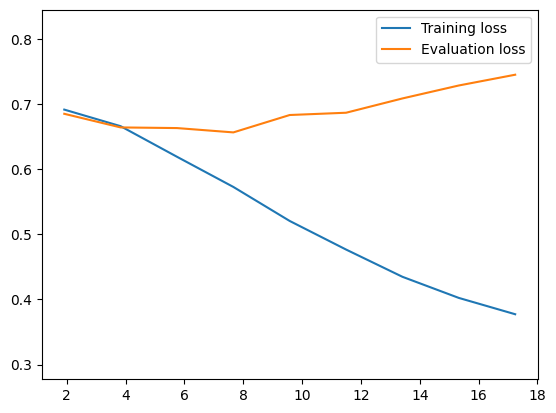

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt

def plot(logs, keys, labels):
    values = sum([logs[k] for k in keys], [])
    plt.ylim(max(min(values)-0.1, 0.0), min(max(values)+0.1, 1.0))
    for key, label in zip(keys, labels):
        plt.plot(logs["epoch"], logs[key], label=label)
    plt.legend()
    plt.show()

plot(training_logs.logs, ["loss", "eval_loss"], ["Training loss", "Evaluation loss"])

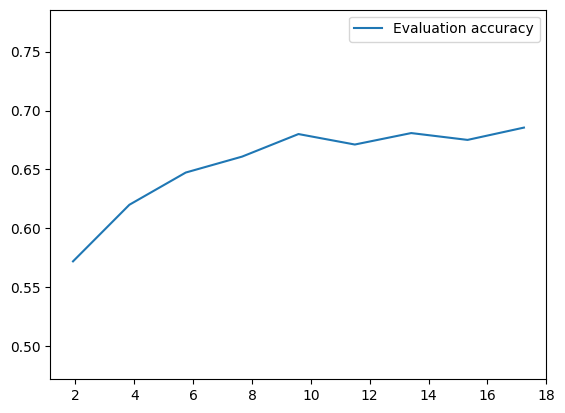

In [18]:
plot(training_logs.logs, ["eval_accuracy"], ["Evaluation accuracy"])

The model has barely learned anything. What's going on? Can you improve on the performance e.g. by modifying the hyperparameters?

<a href="https://colab.research.google.com/github/TurkuNLP/Deep_Learning_in_LangTech_course/blob/master/hf_trainer_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN model:

# Setup

First, set up the required Python modules and perform some general configuration.

Install the required Python packages using [pip](https://en.wikipedia.org/wiki/Pip):

* [`transformers`](https://huggingface.co/docs/transformers/index) is a popular deep learning package
* [`datasets`](https://huggingface.co/docs/datasets/) provides support for loading, creating, and manipulating datasets
* [`evaluate`](https://huggingface.co/docs/evaluate/index) is a library for easily evaluating machine learning models and datasets
* [`accelerate`](https://pypi.org/project/accelerate/) is a wrapper we need to install in order to train torch models using a transformers trainer

Both `transformers` and `datasets` are used extensively on this course.

In [1]:
# !pip3 install -q transformers datasets evaluate accelerate

(Above, the `!` at the start of the line tells the notebook to run the line as an operating system command rather than Python code, and the `-q` argument to `pip` runs the command in "quiet" mode, with less output.)

We'll also use the [`pprint`](https://docs.python.org/3/library/pprint.html) ("pretty-print") module to format output more readably below. The only difference to just using `print` is that some data structures will be easier to read and interpret.

In [2]:
from pprint import PrettyPrinter

pprint = PrettyPrinter(compact=True).pprint

Finally, we will reduce logging output. The `transformers` library by default produces fairly verbose logging. Commenting out the following code will enable low-priority output (`INFO` logging level and below).

In [3]:
import logging

logging.disable(logging.INFO)

# Basic training pipeline: Steps

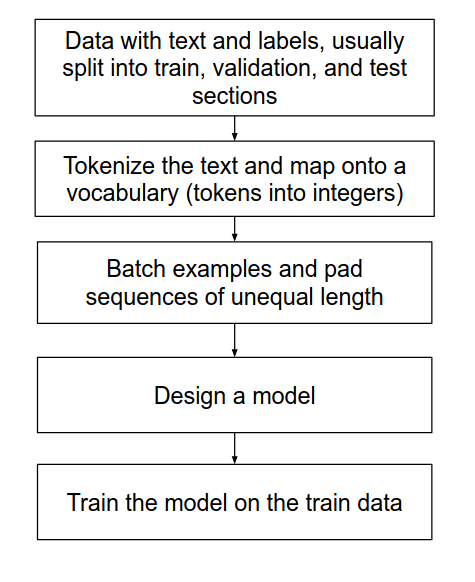

---

# Download and prepare data

We will use the `datasets` library function [`load_dataset`](https://huggingface.co/docs/datasets/master/en/package_reference/loading_methods#datasets.load_dataset) to load a dataset for our experiments.

In [4]:
import datasets


dataset = datasets.load_dataset('stanfordnlp/imdb')

Let's see what the dataset contains:

In [5]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


and print out an example:

In [6]:
dataset = dataset.shuffle() #This is never a bad idea, datasets may have ordering to them, which is not what we want
del dataset["unsupervised"] # Delete the unlabeled part of the dataset to make things faster
pprint(dataset['train'][0])

{'label': 1,
 'text': 'Erich Rohmer\'s "L\'Anglaise et le duc" makes a perfect companion '
         'piece to Peter Watkins\' "La Commune (Paris 1871)." Both films '
         "-screened at this year's Toronto International Film Festival- "
         'ironically illustrate how history is shaped to by the tellers of the '
         'tale. Ironic, given the tragic events that were taking place in the '
         'U.S. during the festival.<br /><br />Set in Paris during the French '
         "Revolution, the movie, based on Grace Elliott's (Lucy Russell) "
         '"Memoirs," is a first-hand account of how she survived those heady '
         'but dangerous days. She also details her relationship with The Duke '
         'of Orleans (played by Jean-Claude Dreyfus), who, in contrast to '
         'herself, is a supporter of the Revolution.<br /><br />True to form, '
         "you don't know whose side of history Rohmer is going to come down "
         'on. One of the earliest of the French "Ne

---

# Tokenize and vectorize data

To tokenize and vectorize the texts of our dataset, we will use previously created tokenizers through the simple [`AutoTokenizer`](https://huggingface.co/docs/transformers/model_doc/auto#transformers.AutoTokenizer) class.

The [`AutoTokenizer.from_pretrained`](https://huggingface.co/docs/transformers/model_doc/auto#transformers.AutoTokenizer.from_pretrained) function can load the tokenizer associated with any of the large number of models found in the [Hugging Face models repository](https://huggingface.co/models). Here, our texts are in English, and we'll load the tokenizer for the [`bert-base-cased`](https://huggingface.co/bert-base-cased) model.

(**Note**: we're not actually using the BERT model here, just its tokenizer.)

In [7]:
import transformers

model_name = "bert-base-cased"
tokenizer = transformers.AutoTokenizer.from_pretrained(model_name)

The tokenizers in the transformers library take a text string as argument and both split the text into tokens (tokenization) and map those tokens into integer identifiers (vectorization).

The values returned by the tokenizer depend on the model that the tokenizer was created for, but normally include at least `input_ids`, which are the result of tokenization and vectorization:

In [8]:
pprint(tokenizer.tokenize("This is an example sentence."))
pprint(tokenizer("This is an example sentence."))

['This', 'is', 'an', 'example', 'sentence', '.']
{'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1],
 'input_ids': [101, 1188, 1110, 1126, 1859, 5650, 119, 102],
 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0]}


We can ignore the values other than `input_ids` returned by the tokenizer (`token_type_ids` and `attention_mask`) for now. We will come back to these later in the course.

We can now tokenize and vectorize our whole dataset with the tokenizer by defining a simple tokenization function and calling the [`Dataset.map`](https://huggingface.co/docs/datasets/v2.14.4/en/package_reference/main_classes#datasets.Dataset.map) function.

If the function returns a column that already exists, then it overwrites the value, otherwise it adds a new column. Here, the call adds the values returned by the tokenizer() call (input_ids etc.) to each example while also keeping the original text and label values.

Note that here we're providing a `max_length` argument and `truncation=True` in the tokenizer call. This limits the maximum length of outputs to the given length (see the [tokenizers documentation](https://huggingface.co/docs/transformers/preprocessing#everything-you-always-wanted-to-know-about-padding-and-truncation) for details). This makes training faster, potentially at some cost in performance.

In [9]:
# Define a simple function that applies the tokenizer
def tokenize(example):
    return tokenizer(
        example["text"],
        max_length=128,
        truncation=True,
    )

# Apply the tokenizer to the whole dataset using .map()
dataset = dataset.map(tokenize)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

In [10]:
pprint(dataset["train"][0])

{'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
                    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
                    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
                    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
                    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
                    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
                    1, 1, 1, 1, 1, 1, 1, 1],
 'input_ids': [101, 18773, 155, 10559, 4027, 112, 188, 107, 149, 112, 26285,
               20737, 2217, 3084, 5837, 3840, 1665, 107, 2228, 170, 3264, 8573,
               2727, 1106, 1943, 18190, 112, 107, 2001, 3291, 6262, 10038, 113,
               2123, 6899, 114, 119, 107, 2695, 2441, 118, 12468, 1120, 1142,
               1214, 112, 188, 3506, 1570, 2352, 2263, 118, 22564, 2716, 20873,
               1293, 1607, 1110, 4283, 1106, 1118, 1103, 1587, 1468, 1104, 1103,

---

# Build model

A PyTorch model class should have an `__init__()` function which instantiates the layers and a `forward()` function which implements the actual computation. For more information on these, please see the [PyTorch tutorial](https://pytorch.org/tutorials/beginner/introyt/modelsyt_tutorial.html).

We're here building a simple version of the CNN text classification model proposed by [Kim (2014) _Convolutional Neural Networks for Sentence Classification_](https://arxiv.org/pdf/1408.5882.pdf).

The architecture of our simplified version is illustrated in the following figure:

![foo](https://raw.githubusercontent.com/TurkuNLP/Deep_Learning_in_LangTech_course/master/figs/simple-cnn.png)

The model has the following architecture:

* First, the token IDs are mapped to embeddings of a user-specified size (`config.embedding_dim`) in a [torch.nn.Embedding](https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html) layer. Note that here the embeddings are initialized randomly and learned along with other model weights. In real-world applications, the embeddings would often be initialized with previously learned weights.
* Second, a user-specified number of filters (`config.num_filters`) is applied to the matrix formed by the sequence of token embedding in a convolution layer ([torch.nn.Conv1d](https://pytorch.org/docs/stable/generated/torch.nn.Conv1d.html)). As explained on the previous lecture, the width of the filters matches the width of the embeddings, and the convolution is one-dimensional. The filter weights are initialized randomly and learned along with other model weights, as is common in CNN models.
* Third, the outputs of the convolution are passed through a non-linear activation function, here the simple ReLU ([torch.nn.ReLU](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html)) which thresholds each value at 0 ($\textrm{max}(0,x)$, i.e. any value < 0 is set to 0).  
* Next, the outputs are max-pooled globally using [torch.nn.AdaptiveMaxPool1d](https://pytorch.org/docs/stable/generated/torch.nn.AdaptiveMaxPool1d.html), taking only the largest value output by each of the filters (after the activation function). This introduces _translation invariance_: the pooled output contains information on how well each filter "matched" the input, but not _where_ that "match" was found.
* Finally, there is a fully connected layer ([torch.nn.Linear](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html)) that maps the pooled values to the two possible output values.

We can interpret this model as attempting to learn _n_-gram feature detectors (the filters, where _n_ is the filter size) for statements that express either positive or negative opinions in a way that is independent of _where_ in the input the _n_-gram feature appears.

In the `forward` function we mostly just pass the input through the various layers, with the following additional steps:

* After the embedding layer, we call [permute](https://pytorch.org/docs/stable/generated/torch.permute.html) to reorder the last two dimensions from (embedding-index, word-sequence-position) to (word-sequence-position, embedding-index) as [torch.nn.Conv1d](https://pytorch.org/docs/stable/generated/torch.nn.Conv1d.html) expects this order.
* After the pooling layer, we call [flatten](https://pytorch.org/docs/stable/generated/torch.flatten.html) to drop a dimension of size one left by the pooling, producing a vector for each example in the batch. (Note `start_dim=1` here to avoid flattening the whole batch of examples.)

(These steps can be considered technical details and understanding them in detail is not required to understand the model.)

In [11]:
import torch


# This gives a new name to the config class, just for convenience
BasicConfig = transformers.PretrainedConfig


# This is the model
class SimpleCNN(transformers.PreTrainedModel):

    config_class = BasicConfig

    # In the initialization method, one instantiates the layers
    # these will be the parameters of the model
    def __init__(self, config):
        super().__init__(config)
        # Embedding layer: vocab size x embedding dim
        self.embeddings = torch.nn.Embedding(
            num_embeddings=config.vocab_size,
            embedding_dim=config.embedding_dim
        )
        # Convolution layer
        self.convolution = torch.nn.Conv1d(
            config.embedding_dim,
            config.num_filters,
            config.filter_size,
            padding=1
        )
        # Activation function following convolution
        self.activation = torch.nn.ReLU()
        # Pooling layer: global max pooling, regardless of input length
        self.pooling_layer = torch.nn.AdaptiveMaxPool1d(
            output_size=1
        )
        # Output layer: num filters to output size
        self.output_layer = torch.nn.Linear(
            in_features=config.num_filters,
            out_features=config.num_labels
        )
        # Loss function: standard loss for classification
        self.loss = torch.nn.CrossEntropyLoss()

    def forward(self, input_ids, labels=None, attention_mask=None):
        #shape of input: [batch_size, maxlen]
        x = self.embeddings(input_ids)
        #shape of x: [batch_size, maxlen, embedding_dim]
        x = x.permute((0,2,1))
        #shape of x: [batch_size, embedding_dim, maxlen]
        x = self.convolution(x)
        #shape of x: [batch_size, filters, maxlen]
        x = self.activation(x)
        #shape of x: [batch_size, filters, maxlen]
        x = self.pooling_layer(x)
        #shape of x: [batch_size, filters, 1]
        x = x.flatten(start_dim=1)
        #shape of x: [batch_size, filters]
        output = self.output_layer(x)

        # Return value computed as in the MLP:
        if labels is not None:
            # We have labels, so we can calculate the loss
            return (self.loss(output,labels), output)
        else:
            # No labels, so just return the output
            return (output,)

# Configure model

We'll first configure and instantiate the model. Here `vocab_size` should always be the vocabulary size of the tokenizer and `num_labels` the number of unique labels in the data (as here), but the other three are hyperparameters that you can choose:

* `embedding_dim`: the size of the word (i.e. token) embeddings
* `filter_size`: the size ("length") of the convolution filters (2 for bigrams, 3 for 3-grams, etc.)
* `num_filters`: the number of different convolution filters

In [12]:
config = BasicConfig(
    vocab_size = tokenizer.vocab_size,
    num_labels = len(set(dataset['train']['label'])),
    embedding_dim = 64,
    filter_size = 3,
    num_filters = 10,
)

model = SimpleCNN(config)

# Train model

We will use the Hugging Face [Trainer](https://huggingface.co/docs/transformers/main_classes/trainer) class for training

* Loads of arguments that control the training
* Configurable metrics to evaluate performance
* Data collator builds the batches
* Early stopping callback stops when eval loss no longer improves


First, let's create a TrainingArguments object to specify hyperparameters and various other settings for training.

Printing this simple dataclass object will show not only the values we set, but also the defaults for all other arguments. Many are not relevant to us here, but the following are hyperparameters that you may wish to adjust:

* `learning_rate`: the step size for weight updates
* `per_device_train_batch_size`: number of examples per batch
* `max_steps`: the maximum number of steps to train for

In [13]:
# Set training arguments
trainer_args = transformers.TrainingArguments(
    "checkpoints",
    eval_strategy="steps",
    logging_strategy="steps",
    load_best_model_at_end=True,
    eval_steps=500,
    logging_steps=1000,
    learning_rate=0.005,
    per_device_train_batch_size=32,
    max_steps=5000,
    report_to="none",
)

| Values | Training loss | Validation loss | Accuracy |
| :- | :- | :- | :- |
| learning_rate=0.0001, per_device_train_batch_size=32, max_steps=2500, | 0.675597 | 0.680877 | 0.568800
| learning_rate=0.00001, per_device_train_batch_size=32, max_steps=2500, | 0.715553	| 0.712621 | 0.501440
| learning_rate=0.0001, per_device_train_batch_size=16, max_steps=2500, | 0.682035 | 0.683950 | 0.551920
| learning_rate=0.0001, per_device_train_batch_size=16, max_steps=5000, | 0.656037 | 0.666850 | 0.597040
| learning_rate=0.0001, per_device_train_batch_size=32, max_steps=5000, | 0.629270 | 0.641460 | 0.636480
| learning_rate=0.0001, per_device_train_batch_size=64, max_steps=5000, | 0.649830 | 0.662695 | 0.600520
| learning_rate=0.0001, per_device_train_batch_size=32, max_steps=7500, | 0.634373 | 0.649321 | 0.624640
| learning_rate=0.001, per_device_train_batch_size=32, max_steps=7500, | 0.271565 | 0.533169 | 0.753840
| learning_rate=0.005, per_device_train_batch_size=32, max_steps=5000, | 0.099750 | 0.728336 | 0.763320
| learning_rate=0.005, per_device_train_batch_size=64, max_steps=5000, | 0.009310 | 1.011595 | 0.758240

Next, let's create a metric for evaluating performance during and after training. We can use the convenience function `evaluate.load` to load one of many pre-made metrics and wrap this for use by the trainer.

As the task is simple multi-class classification, we'll use the basic `accuracy` metric, defined as the proportion of correctly predicted labels out of all labels.

We'll yet need to create a [DataCollatorWithPadding](https://huggingface.co/docs/transformers/main_classes/data_collator#transformers.DataCollatorWithPadding) to pad inputs to the same length (as required for batching) and an [EarlyStoppingCallback](https://huggingface.co/docs/transformers/main_classes/callback#transformers.EarlyStoppingCallback) to stop training when performance fails to improve for the given number of evaluations.

In [14]:
import evaluate

accuracy = evaluate.load("accuracy")


def compute_accuracy(outputs_and_labels):
    outputs, labels = outputs_and_labels
    predictions = outputs.argmax(axis=-1) #pick the index of the "winning" label
    return accuracy.compute(predictions=predictions, references=labels)

data_collator = transformers.DataCollatorWithPadding(tokenizer)

# Argument gives the number of steps of patience before early stopping
early_stopping = transformers.EarlyStoppingCallback(
    early_stopping_patience=3
)

Finally, we'll create a simple custom [callback](https://huggingface.co/docs/transformers/main_classes/callback) to store values logged during training so that we can more easily examine them later. (This is only needed for visualization and is not necessary to understand in detail.)

In [15]:
from collections import defaultdict

class LogSavingCallback(transformers.TrainerCallback):
    def on_train_begin(self, *args, **kwargs):
        self.logs = defaultdict(list)
        self.training = True

    def on_train_end(self, *args, **kwargs):
        self.training = False

    def on_log(self, args, state, control, logs, model=None, **kwargs):
        if self.training:
            for k, v in logs.items():
                if k != "epoch" or v not in self.logs[k]:
                    self.logs[k].append(v)

training_logs = LogSavingCallback()

We then pass the model, trainer arguments, training and evaluation data, metric, the collator, and the callback to a [Trainer](https://huggingface.co/docs/transformers/main_classes/trainer) and call `.train()` to train the model.

In [16]:
trainer = transformers.Trainer(
    model=model,
    args=trainer_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    compute_metrics=compute_accuracy,
    data_collator=data_collator,
    callbacks=[early_stopping, training_logs]
)

trainer.train()

/home/lauris/Documents/school/2026-27/Deep-Learning/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss,Validation Loss,Accuracy
500,No log,0.553126,0.707760
1000,0.556529,0.498909,0.755280
1500,0.556529,0.500404,0.762400
2000,0.380010,0.523499,0.766680
2500,0.380010,0.560479,0.770720


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/home/lauris/Documents/school/2026-27/Deep-Learning/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

/home/lauris/Documents/school/2026-27/Deep-Learning/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/home/lauris/Documents/school/2026-27/Deep-Learning/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2500, training_loss=0.4281835327148438, metrics={'train_runtime': 26.0609, 'train_samples_per_second': 6139.467, 'train_steps_per_second': 191.858, 'total_flos': 119822942208.0, 'train_loss': 0.4281835327148438, 'epoch': 3.1969309462915603})

---

# Results

Evaluate and print out results:

In [17]:
# eval_results = trainer.evaluate(dataset["test"])

# pprint(eval_results)

# print('Accuracy:', eval_results['eval_accuracy'])

Let's also have a look at training and evaluation loss and evaluation accuracy progression. (The code here is only for visualization and you do not need to understand it, but you should aim to be able to interpret the plots.)

ValueError: x and y must have same first dimension, but have shapes (5,) and (2,)

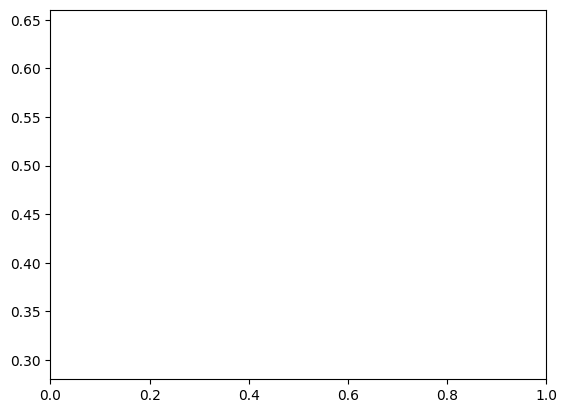

In [18]:
%matplotlib inline
import matplotlib.pyplot as plt

def plot(logs, keys, labels):
    values = sum([logs[k] for k in keys], [])
    plt.ylim(max(min(values)-0.1, 0.0), min(max(values)+0.1, 1.0))
    for key, label in zip(keys, labels):
        plt.plot(logs["epoch"], logs[key], label=label)
    plt.legend()
    plt.show()

plot(training_logs.logs, ["loss", "eval_loss"], ["Training loss", "Evaluation loss"])

In [ ]:
plot(training_logs.logs, ["eval_accuracy"], ["Evaluation accuracy"])

Both losses are decreasing and accuracy has improved over the 50% baseline, so the model is definitely learning. However, this is not a particularly high level of performance for this data (MLP with BoW features is ~87%).

Can you improve on the performance e.g. by modifying the model structure or the training hyperparameters?